In [1]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch Version: 2.11.0+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


<a href="https://colab.research.google.com/github/nikithadayanand04/FileExplorer/blob/main/PalmPayModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

print(os.getcwd())

C:\Users\jashu\Downloads


In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    if dirs:
        print(root, dirs[:5])

PHASE-1: DATASET VALIDATION

In [4]:
import os
import cv2
import numpy as np
import pandas as pd

HAND_PATH = r"C:\Users\jashu\Downloads\dataset\Hand_Dataset"
VEIN_PATH = r"C:\Users\jashu\Downloads\dataset\Veins_Dataset"

In [5]:
import os

print("Hand subjects:", len(os.listdir(HAND_PATH)))
print("Vein subjects:", len(os.listdir(VEIN_PATH)))

Hand subjects: 60
Vein subjects: 60


In [6]:
subjects = sorted([
    s for s in os.listdir(HAND_PATH)
    if os.path.isdir(os.path.join(HAND_PATH, s))
])

print("Total Subjects:", len(subjects))

Total Subjects: 60


In [7]:
sizes = []

for subject in subjects:

    folder = os.path.join(HAND_PATH, subject)

    for img_name in os.listdir(folder):

        path = os.path.join(folder, img_name)

        img = cv2.imread(path, 0)

        sizes.append(img.shape)

print(pd.Series(sizes).value_counts())

(480, 640)    600
Name: count, dtype: int64


PHASE-2: ROI EXTRACTION

Cell 1 — Import Libraries

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Cell 2 — Load Sample Image

Shape: (480, 640)


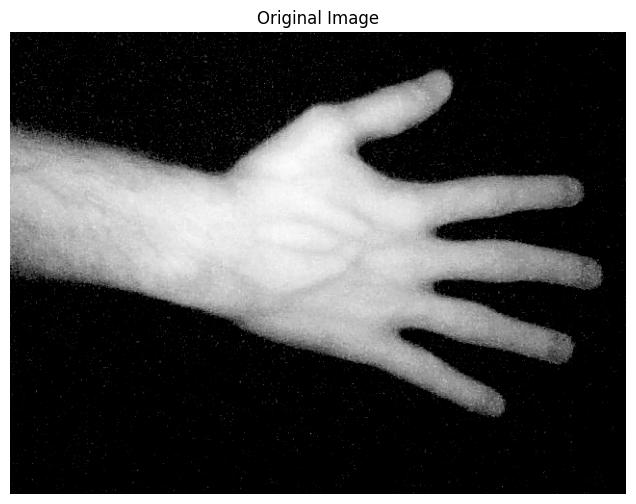

In [9]:
sample_path = f"{HAND_PATH}/s1/1.bmp"

img = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

print("Shape:", img.shape)

plt.figure(figsize=(8,6))
plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

Cell 3 — Hand Segmentation

In [10]:
def segment_hand(img):

    blur = cv2.GaussianBlur(
        img,
        (5,5),
        0
    )

    _, mask = cv2.threshold(
        blur,
        20,
        255,
        cv2.THRESH_BINARY
    )

    kernel = np.ones((5,5),np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    return mask

Cell 4 — Visualize Hand Mask

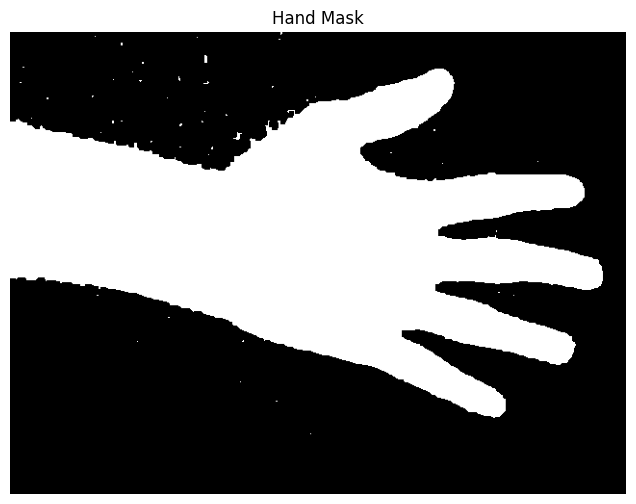

In [11]:
mask = segment_hand(img)

plt.figure(figsize=(8,6))
plt.imshow(mask,cmap='gray')
plt.title("Hand Mask")
plt.axis('off')
plt.show()

Cell 5 — Find Largest Contour

In [12]:
def get_largest_contour(mask):

    contours,_ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    largest = max(
        contours,
        key=cv2.contourArea
    )

    return largest

Cell 6 — Draw Contour

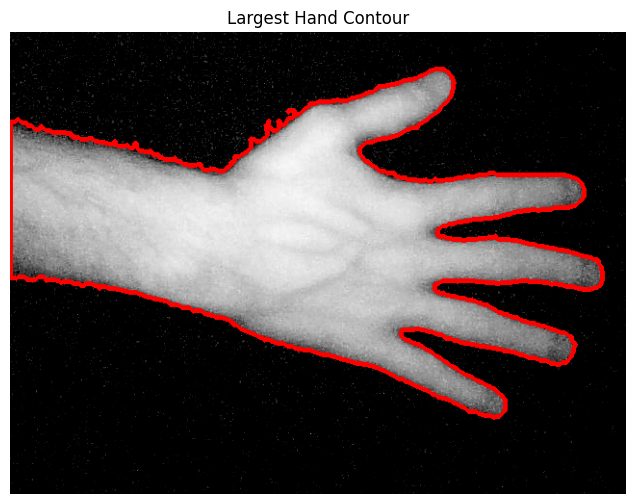

In [13]:
contour = get_largest_contour(mask)

rgb = cv2.cvtColor(
    img,
    cv2.COLOR_GRAY2RGB
)

cv2.drawContours(
    rgb,
    [contour],
    -1,
    (255,0,0),
    3
)

plt.figure(figsize=(8,6))
plt.imshow(rgb)
plt.title("Largest Hand Contour")
plt.axis('off')
plt.show()

Cell 7 — Palm Center Detection

In [14]:
def get_palm_center(contour):

    M = cv2.moments(contour)

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    return cx,cy

Cell 8 — Visualize Palm Center

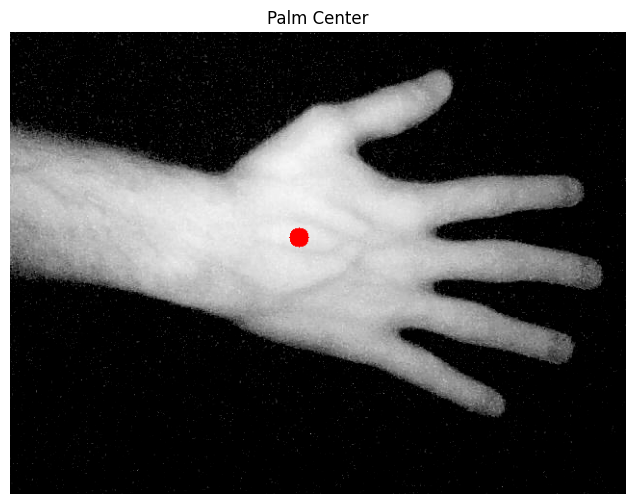

In [15]:
cx,cy = get_palm_center(contour)

rgb = cv2.cvtColor(
    img,
    cv2.COLOR_GRAY2RGB
)

cv2.circle(
    rgb,
    (cx,cy),
    10,
    (255,0,0),
    -1
)

plt.figure(figsize=(8,6))
plt.imshow(rgb)
plt.title("Palm Center")
plt.axis('off')
plt.show()

Cell 9 — Final ROI Extraction

In [16]:
def extract_palm_roi(img):

    mask = segment_hand(img)

    contour = get_largest_contour(mask)

    cx,cy = get_palm_center(contour)

    roi_size = 220

    x1 = max(cx - roi_size//2,0)
    y1 = max(cy - roi_size//2,0)

    x2 = min(cx + roi_size//2,img.shape[1])
    y2 = min(cy + roi_size//2,img.shape[0])

    roi = img[y1:y2,x1:x2]

    roi = cv2.resize(
        roi,
        (224,224)
    )

    return roi

Cell 10 — Generate ROI

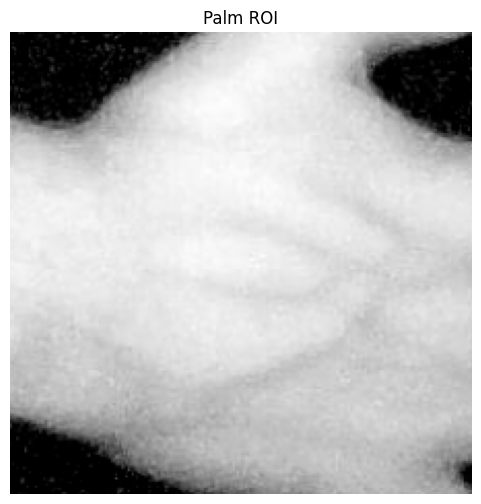

In [17]:
roi = extract_palm_roi(img)

plt.figure(figsize=(6,6))
plt.imshow(
    roi,
    cmap='gray'
)

plt.title("Palm ROI")
plt.axis('off')
plt.show()

Cell 11 — Verify ROI on Multiple Subjects

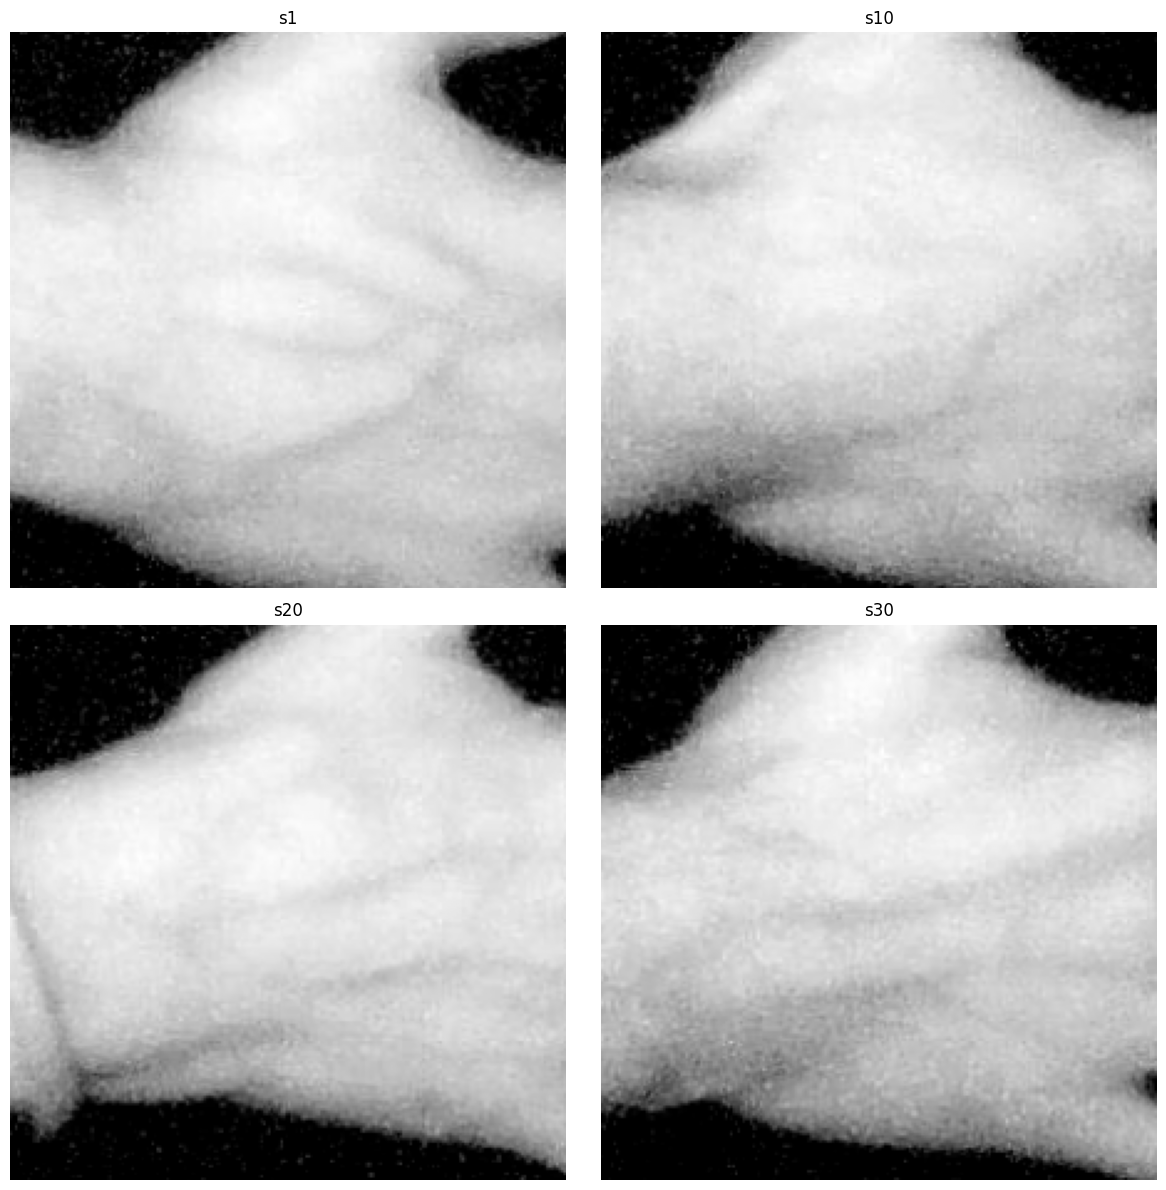

In [18]:
samples = [
    ("s1","1.bmp"),
    ("s10","1.bmp"),
    ("s20","1.bmp"),
    ("s30","1.bmp")
]

plt.figure(figsize=(12,12))

for i,(subject,image) in enumerate(samples):

    path = f"{HAND_PATH}/{subject}/{image}"

    img = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    roi = extract_palm_roi(img)

    plt.subplot(2,2,i+1)
    plt.imshow(roi,cmap='gray')
    plt.title(subject)
    plt.axis('off')

plt.tight_layout()
plt.show()

PHASE 3 — PALM VEIN IMAGE ENHANCEMENT

CELL 1 — Denoising Function

In [19]:
def denoise_image(img):

    denoised = cv2.medianBlur(
        img,
        5
    )

    return denoised

CELL 2 — Apply Denoising

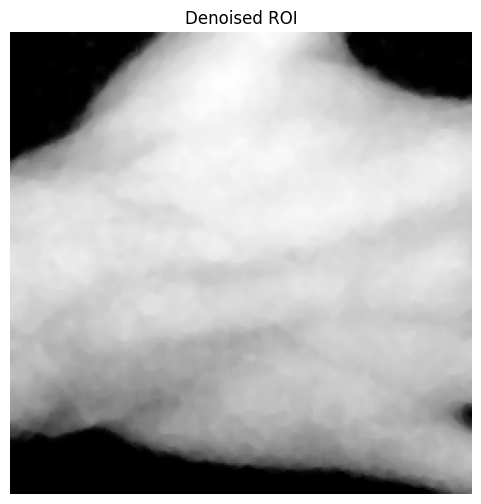

In [20]:
denoised = denoise_image(roi)

plt.figure(figsize=(6,6))

plt.imshow(
    denoised,
    cmap='gray'
)

plt.title(
    "Denoised ROI"
)

plt.axis('off')
plt.show()

CELL 3 — CLAHE Function

In [21]:
def apply_clahe(img):

    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(img)

    return enhanced

CELL 4 — Apply CLAHE

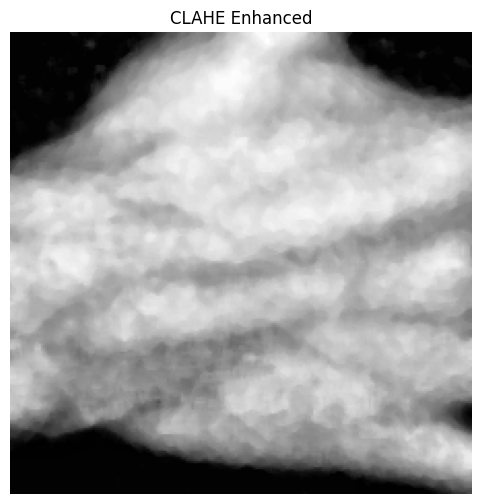

In [22]:
clahe_img = apply_clahe(
    denoised
)

plt.figure(figsize=(6,6))

plt.imshow(
    clahe_img,
    cmap='gray'
)

plt.title(
    "CLAHE Enhanced"
)

plt.axis('off')
plt.show()

CELL 5 — Gaussian Normalization Function

In [23]:
def gaussian_normalization(img):

    blur = cv2.GaussianBlur(
        img,
        (5,5),
        0
    )

    normalized = cv2.addWeighted(
        img,
        1.5,
        blur,
        -0.5,
        0
    )

    return normalized

CELL 6 — Apply Gaussian Normalization

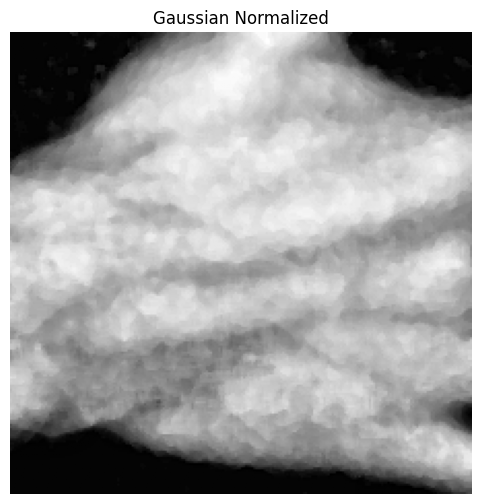

In [24]:
gaussian_img = gaussian_normalization(
    clahe_img
)

plt.figure(figsize=(6,6))

plt.imshow(
    gaussian_img,
    cmap='gray'
)

plt.title(
    "Gaussian Normalized"
)

plt.axis('off')
plt.show()

CELL 7 — Intensity Normalization Function

In [25]:
def normalize_image(img):

    normalized = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return normalized.astype(
        np.uint8
    )

CELL 8 — Apply Intensity Normalization

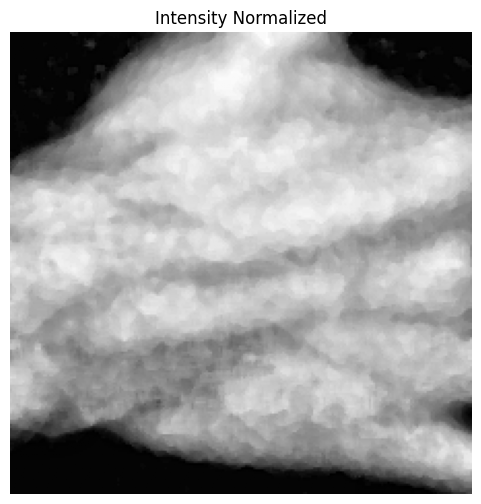

In [26]:
normalized_img = normalize_image(
    gaussian_img
)

plt.figure(figsize=(6,6))

plt.imshow(
    normalized_img,
    cmap='gray'
)

plt.title(
    "Intensity Normalized"
)

plt.axis('off')
plt.show()

CELL 9 — Gamma Correction Function

In [27]:
def gamma_correction(
    image,
    gamma=1.5
):

    image = image / 255.0

    corrected = np.power(
        image,
        gamma
    )

    corrected = corrected * 255

    return corrected.astype(
        np.uint8
    )

CELL 10 — Apply Gamma Correction

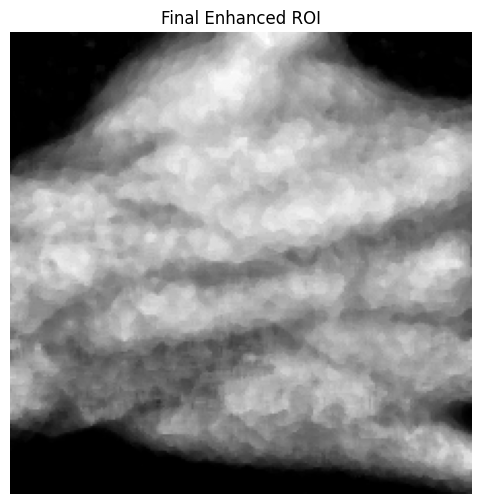

In [28]:
enhanced_roi = gamma_correction(
    normalized_img,
    gamma=1.5
)

plt.figure(figsize=(6,6))

plt.imshow(
    enhanced_roi,
    cmap='gray'
)

plt.title(
    "Final Enhanced ROI"
)

plt.axis('off')
plt.show()

CELL 11 — Complete Comparison

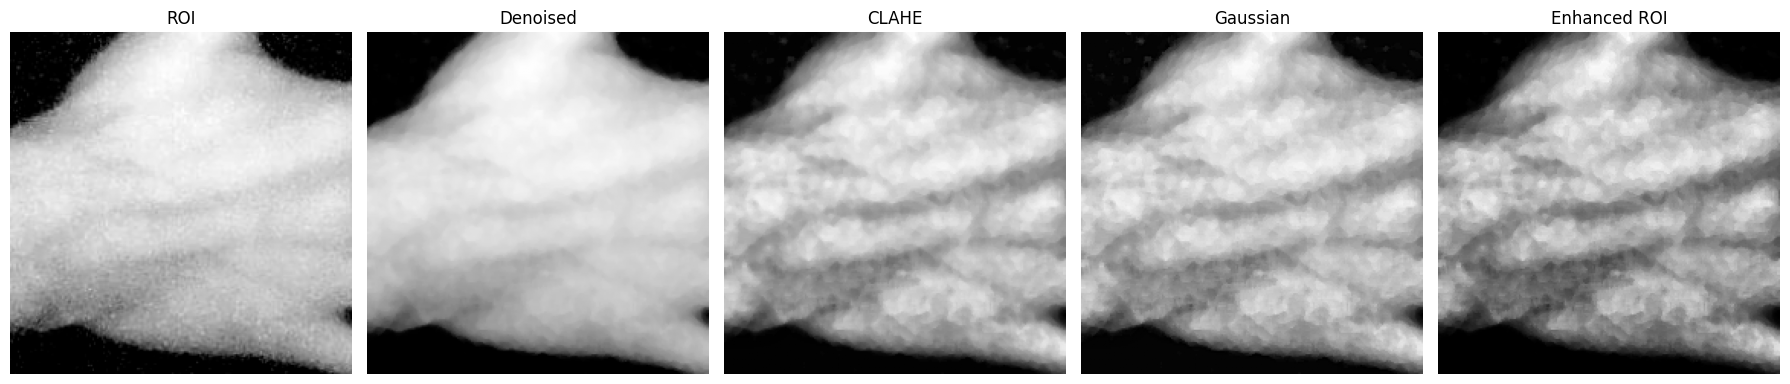

In [29]:
plt.figure(figsize=(18,5))

plt.subplot(1,5,1)
plt.imshow(
    roi,
    cmap='gray'
)
plt.title("ROI")
plt.axis('off')

plt.subplot(1,5,2)
plt.imshow(
    denoised,
    cmap='gray'
)
plt.title("Denoised")
plt.axis('off')

plt.subplot(1,5,3)
plt.imshow(
    clahe_img,
    cmap='gray'
)
plt.title("CLAHE")
plt.axis('off')

plt.subplot(1,5,4)
plt.imshow(
    gaussian_img,
    cmap='gray'
)
plt.title("Gaussian")
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(
    enhanced_roi,
    cmap='gray'
)
plt.title("Enhanced ROI")
plt.axis('off')

plt.tight_layout()
plt.show()

CELL 12 — Save Final ROI Variable

In [30]:
final_roi = enhanced_roi

print(
    "Final ROI Shape:",
    final_roi.shape
)

Final ROI Shape: (224, 224)


PHASE 4: DATASET PAIRING AND DATA PREPARATION FOR VEIN SEGMENTATION

CELL 1 — Imports

In [31]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

CELL 2 — Create Hand–Vein Image Pairs

In [32]:
pairs = []

subjects = sorted(
    [
        s for s in os.listdir(HAND_PATH)
        if os.path.isdir(
            os.path.join(HAND_PATH,s)
        )
    ]
)

for subject in subjects:

    hand_subject = os.path.join(
        HAND_PATH,
        subject
    )

    vein_subject = os.path.join(
        VEIN_PATH,
        subject
    )

    images = sorted(
        [
            f for f in os.listdir(hand_subject)
            if f.endswith(".bmp")
        ]
    )

    for img_name in images:

        image_path = os.path.join(
            hand_subject,
            img_name
        )

        mask_path = os.path.join(
            vein_subject,
            img_name
        )

        if os.path.exists(mask_path):

            pairs.append(
                [
                    subject,
                    image_path,
                    mask_path
                ]
            )

CELL 3 — Generate Dataset Metadata DataFrame

In [33]:
df = pd.DataFrame(
    pairs,
    columns=[
        "subject",
        "image_path",
        "mask_path"
    ]
)

print(df.shape)

df.head()

(600, 3)


,subject,image_path,mask_path
0,s1,C:\Users\jashu\Downloads\dataset\Hand_Dataset\...,C:\Users\jashu\Downloads\dataset\Veins_Dataset...
1,s1,C:\Users\jashu\Downloads\dataset\Hand_Dataset\...,C:\Users\jashu\Downloads\dataset\Veins_Dataset...
2,s1,C:\Users\jashu\Downloads\dataset\Hand_Dataset\...,C:\Users\jashu\Downloads\dataset\Veins_Dataset...
3,s1,C:\Users\jashu\Downloads\dataset\Hand_Dataset\...,C:\Users\jashu\Downloads\dataset\Veins_Dataset...
4,s1,C:\Users\jashu\Downloads\dataset\Hand_Dataset\...,C:\Users\jashu\Downloads\dataset\Veins_Dataset...


CELL 4 - Verify Image–Mask Pair Mapping

In [34]:
print(df.iloc[0]["image_path"])

print(df.iloc[0]["mask_path"])

C:\Users\jashu\Downloads\dataset\Hand_Dataset\s1\1.bmp
C:\Users\jashu\Downloads\dataset\Veins_Dataset\s1\1.bmp


CELL 5 - Define Subject-Wise Dataset Split

In [35]:
subjects = sorted(
    df.subject.unique()
)

train_subjects = subjects[:42]

val_subjects = subjects[42:51]

test_subjects = subjects[51:]

CELL 6 - Create Train, Validation, and Test Sets

In [36]:
train_df = df[
    df.subject.isin(
        train_subjects
    )
]

val_df = df[
    df.subject.isin(
        val_subjects
    )
]

test_df = df[
    df.subject.isin(
        test_subjects
    )
]

print(
    len(train_df),
    len(val_df),
    len(test_df)
)

420 90 90


CELL 7 - Verify Dataset Distribution

In [37]:
print(
    "Train Subjects:",
    len(train_subjects)
)

print(
    "Val Subjects:",
    len(val_subjects)
)

print(
    "Test Subjects:",
    len(test_subjects)
)

Train Subjects: 42
Val Subjects: 9
Test Subjects: 9


CELL 8 - Define Complete Image Preprocessing Pipeline

In [38]:
def preprocess_image(img):

    roi = extract_palm_roi(img)

    denoised = denoise_image(
        roi
    )

    clahe_img = apply_clahe(
        denoised
    )

    gaussian_img = gaussian_normalization(
        clahe_img
    )

    normalized_img = normalize_image(
        gaussian_img
    )

    enhanced_roi = gamma_correction(
        normalized_img,
        gamma=1.5
    )

    return enhanced_roi

CELL 9 - Validate Preprocessing Pipeline

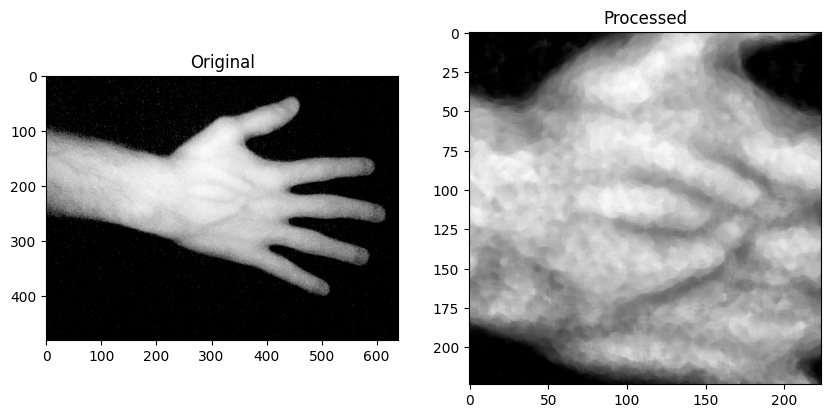

In [39]:
sample_img = cv2.imread(
    train_df.iloc[0]["image_path"],
    cv2.IMREAD_GRAYSCALE
)

processed = preprocess_image(
    sample_img
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(
    sample_img,
    cmap='gray'
)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(
    processed,
    cmap='gray'
)
plt.title("Processed")

plt.show()

CELL 10 - Load Ground Truth Vein Mask

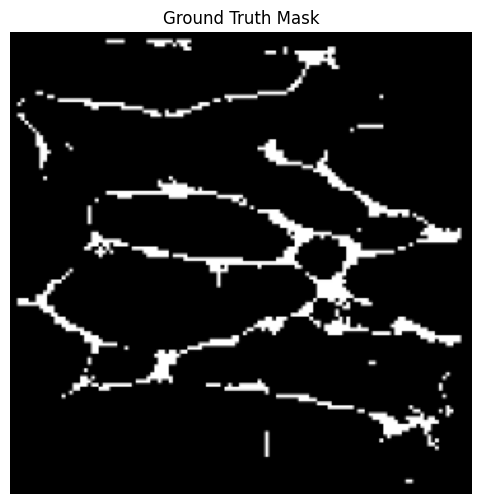

In [40]:
mask = cv2.imread(
    train_df.iloc[0]["mask_path"],
    cv2.IMREAD_GRAYSCALE
)

mask = cv2.resize(
    mask,
    (224,224)
)

plt.figure(figsize=(6,6))

plt.imshow(
    mask,
    cmap='gray'
)

plt.title(
    "Ground Truth Mask"
)

plt.axis('off')
plt.show()

CELL 11 - Verify Image–Mask Alignment

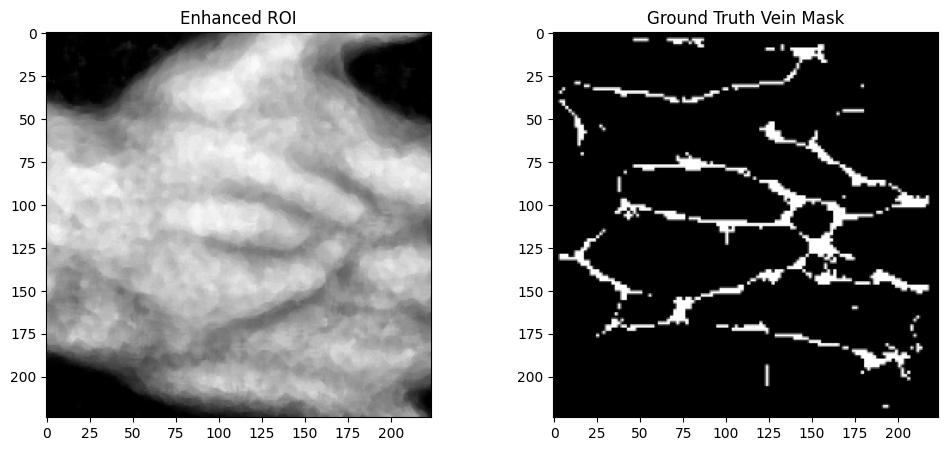

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(
    processed,
    cmap='gray'
)
plt.title(
    "Enhanced ROI"
)

plt.subplot(1,2,2)
plt.imshow(
    mask,
    cmap='gray'
)
plt.title(
    "Ground Truth Vein Mask"
)

plt.show()

In [42]:
import os

BASE_PATH = r"C:\Users\jashu\Downloads\dataset"

print(os.listdir(BASE_PATH))

['Hand_Dataset', 'Veins_Dataset']


In [43]:
import os

for root, dirs, files in os.walk(BASE_PATH):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

    if root.count(os.sep) > BASE_PATH.count(os.sep) + 2:
        break

C:\Users\jashu\Downloads\dataset
Folders: ['Hand_Dataset', 'Veins_Dataset']
Files: []
--------------------------------------------------
C:\Users\jashu\Downloads\dataset\Hand_Dataset
Folders: ['s1', 's10', 's11', 's12', 's13']
Files: []
--------------------------------------------------
C:\Users\jashu\Downloads\dataset\Hand_Dataset\s1
Folders: []
Files: ['1.bmp', '10.bmp', '2.bmp', '3.bmp', '4.bmp']
--------------------------------------------------
C:\Users\jashu\Downloads\dataset\Hand_Dataset\s10
Folders: []
Files: ['1.bmp', '10.bmp', '2.bmp', '3.bmp', '4.bmp']
--------------------------------------------------
C:\Users\jashu\Downloads\dataset\Hand_Dataset\s11
Folders: []
Files: ['1.bmp', '10.bmp', '2.bmp', '3.bmp', '4.bmp']
--------------------------------------------------
C:\Users\jashu\Downloads\dataset\Hand_Dataset\s12
Folders: []
Files: ['1.bmp', '10.bmp', '2.bmp', '3.bmp', '4.bmp']
--------------------------------------------------
C:\Users\jashu\Downloads\dataset\Hand_Dataset